# MCal Experiment: How Calibration Improves Explanation Quality

This notebook demonstrates that MCal calibration improves the quality of feature attribution explanations by:
1. Reducing missingness bias (KL divergence)
2. Improving sufficiency scores
3. Improving comprehensiveness scores

We evaluate these metrics across different values of k (number of top features selected).

## 1. Setup and Imports

In [1]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import pickle

# Add parent directory to path
sys.path.append('..')

# Import our modular components
from experiments.all_data_loaders import load_mri_clean, load_mri_ablated_prob
from experiments.vision.mri_mcal_explanation_quality import load_mri_model
from src.calibrators.mcal_ce import SimpleMCalCE
from experiments.explanations import ImageLIME, ImageKernelSHAP
from experiments.metrics import (
    ImageSufficiency, ImageComprehensiveness, ImageKLDivergence,
    compute_metric_improvement
)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2. Configuration

In [2]:
# Experiment configuration
config = {
    'n_train': 500,           # Training samples for MCal
    'n_test': 500,            # Test samples for evaluation
    'ablation_rate': 0.5,     # Ablation rate for MCal training
    'mcal_steps': 2000,       # Training steps for MCal
    'explanation_method': 'lime',  # 'lime' or 'shap'
    'explanation_samples': 100,     # Samples for explanation generation
    'k_values': list(range(1, 17)), # All 16 k values for 4x4 patch grid
    'batch_size': 32,
    'device': device
}

print("Configuration:")
for key, value in config.items():
    if key != 'k_values':
        print(f"  {key}: {value}")
print(f"  k_values: 1 to 16")

Configuration:
  n_train: 500
  n_test: 500
  ablation_rate: 0.5
  mcal_steps: 2000
  explanation_method: lime
  explanation_samples: 100
  batch_size: 32
  device: cuda
  k_values: 1 to 16


## 3. Load Data and Model

In [3]:
# Load datasets
print("Loading training data...")
train_images, train_labels = load_mri_clean(split='train', n_samples=config['n_train'])
train_images = train_images.to(device)
train_labels = train_labels.to(device)

print("Loading test data...")
test_images, test_labels = load_mri_clean(split='test', n_samples=config['n_test'])
test_images = test_images.to(device)
test_labels = test_labels.to(device)

print(f"Train shape: {train_images.shape}, Test shape: {test_images.shape}")

# Load pre-trained model
print("\nLoading MRI model...")
base_model = load_mri_model().to(device)
base_model.eval()

# Use base model directly as uncalibrated model (outputs logits)
uncal_model = base_model

Loading training data...


Loading data: 100%|██████████| 16/16 [00:01<00:00, 11.85it/s]


Loading test data...


Loading data: 100%|██████████| 16/16 [00:01<00:00, 12.68it/s]


Train shape: torch.Size([500, 3, 224, 224]), Test shape: torch.Size([500, 3, 224, 224])

Loading MRI model...


## 4. Train MCal Calibrator

In [4]:
# Generate ablated training data
print(f"Generating ablated data with p_ablate={config['ablation_rate']}...")
ablated_images, _ = load_mri_ablated_prob(
    split='train', 
    p_ablate=config['ablation_rate'], 
    n_samples=config['n_train']
)
ablated_images = ablated_images.to(device)

# Get model predictions (logits)
print("Computing predictions...")
ablated_logits = []
with torch.no_grad():
    for i in range(0, config['n_train'], config['batch_size']):
        batch = ablated_images[i:i+config['batch_size']]
        ablated_logits.append(base_model(batch))
ablated_logits = torch.cat(ablated_logits, dim=0)

# Train SimpleMCalCE
print("\nTraining MCal calibrator...")
calibrator = SimpleMCalCE(num_classes=4).to(device)

stats = calibrator.fit(
    ablated_logits=ablated_logits,
    target_labels=train_labels,
    max_steps=config['mcal_steps'],
    lr=0.01,
    verbose=True
)

print(f"\nTraining complete!")
print(f"Final Loss: {stats['loss'][-1]:.4f}")
print(f"Final Accuracy: {stats['acc'][-1]:.3f}")

Generating ablated data with p_ablate=0.5...


Loading data: 100%|██████████| 16/16 [00:01<00:00, 13.37it/s]


Computing predictions...

Training MCal calibrator...


Loss: 4.069e-04, Acc: 1.000: 100%|██████████| 2000/2000 [00:01<00:00, 1064.81it/s]



Training complete!
Final Loss: 0.0004
Final Accuracy: 1.000


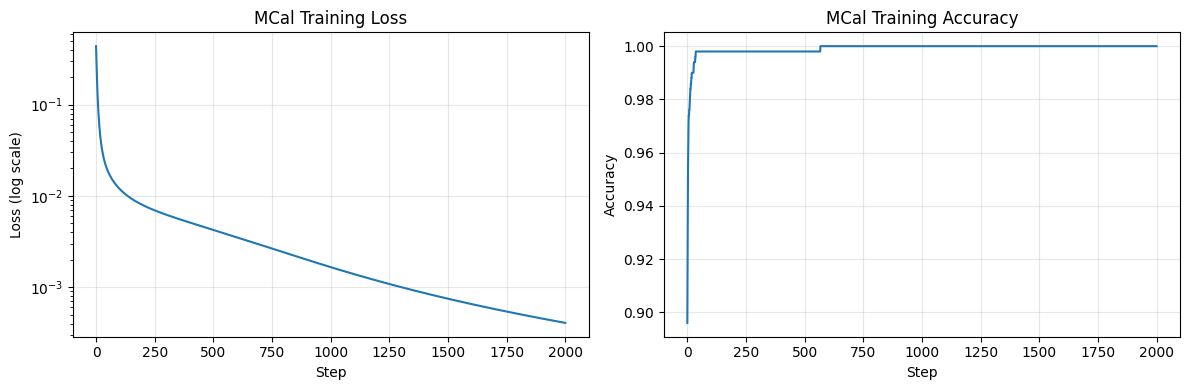

In [5]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(stats['loss'])
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss (log scale)')
ax1.set_title('MCal Training Loss')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Use log scale for loss

ax2.plot(stats['acc'])
ax2.set_xlabel('Step')
ax2.set_ylabel('Accuracy')
ax2.set_title('MCal Training Accuracy')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Create Calibrated Model

In [6]:
# Create calibrated model as sequential composition
calib_model = nn.Sequential(base_model, calibrator)
calib_model.eval()

print("Calibrated model created successfully")

Calibrated model created successfully


## 6. Generate Feature Attributions

In [7]:
# Choose explainer class based on method
if config['explanation_method'] == 'lime':
    ExplainerClass = ImageLIME
else:  # shap
    ExplainerClass = ImageKernelSHAP

print(f"Using {config['explanation_method'].upper()} explainer")

# Initialize explainers
uncal_explainer = ExplainerClass(
    model=uncal_model,
    num_samples=config['explanation_samples'],
    patch_size=56,
    image_size=224
)

calib_explainer = ExplainerClass(
    model=calib_model,
    num_samples=config['explanation_samples'],
    patch_size=56,
    image_size=224
)

print("Explainers initialized")

Using LIME explainer
Explainers initialized


In [8]:
# Generate attributions for all test samples
print(f"Generating {config['explanation_method'].upper()} explanations for {config['n_test']} samples...")

uncal_attrs = []
calib_attrs = []

for i, (image, label) in enumerate(tqdm(zip(test_images, test_labels), total=config['n_test'])):
    uncal_attrs.append(uncal_explainer.explain_instance(image, label.item()))
    calib_attrs.append(calib_explainer.explain_instance(image, label.item()))

print("Explanations generated successfully")

Generating LIME explanations for 500 samples...


100%|██████████| 500/500 [02:18<00:00,  3.61it/s]

Explanations generated successfully


## 7. Evaluate Across Different K Values

In [9]:
# Initialize metrics
kl_metric = ImageKLDivergence(n_classes=4)
suff_metric = ImageSufficiency(patch_size=56, image_size=224)
comp_metric = ImageComprehensiveness(patch_size=56, image_size=224)

# Initialize results storage
results = {
    'k_values': config['k_values'],
    'missingness_bias': {'uncal': [], 'calib': []},
    'sufficiency': {'uncal': [], 'calib': []},
    'comprehensiveness': {'uncal': [], 'calib': []},
    'sufficiency_std': {'uncal': [], 'calib': []},
    'comprehensiveness_std': {'uncal': [], 'calib': []}
}

print("Starting evaluation across k values...")

Starting evaluation across k values...


In [10]:
# Evaluate for each k value
for k in tqdm(config['k_values'], desc="K values"):
    # Storage for this k
    suff_uncal_list = []
    suff_calib_list = []
    comp_uncal_list = []
    comp_calib_list = []
    masked_images_uncal = []
    masked_images_calib = []

    for i, (image, label) in enumerate(zip(test_images, test_labels)):
        label_idx = label.item()

        # Get attributions
        uncal_importance = uncal_attrs[i]
        calib_importance = calib_attrs[i]

        # Compute sufficiency
        suff_uncal = suff_metric.compute(uncal_model, image, uncal_importance, k, label_idx)
        suff_calib = suff_metric.compute(calib_model, image, calib_importance, k, label_idx)
        
        # Compute comprehensiveness
        comp_uncal = comp_metric.compute(uncal_model, image, uncal_importance, k, label_idx)
        comp_calib = comp_metric.compute(calib_model, image, calib_importance, k, label_idx)

        suff_uncal_list.append(suff_uncal)
        suff_calib_list.append(suff_calib)
        comp_uncal_list.append(comp_uncal)
        comp_calib_list.append(comp_calib)

        # Create masked images for KL computation
        uncal_top_k = torch.argsort(torch.abs(uncal_importance), descending=True)[:k]
        calib_top_k = torch.argsort(torch.abs(calib_importance), descending=True)[:k]

        uncal_mask = suff_metric.create_mask_from_indices(uncal_top_k).to(device)
        calib_mask = suff_metric.create_mask_from_indices(calib_top_k).to(device)

        masked_img_uncal = image.clone()
        masked_img_calib = image.clone()
        for c in range(3):
            masked_img_uncal[c] = masked_img_uncal[c] * uncal_mask
            masked_img_calib[c] = masked_img_calib[c] * calib_mask

        masked_images_uncal.append(masked_img_uncal)
        masked_images_calib.append(masked_img_calib)

    # Compute KL divergence
    masked_images_uncal = torch.stack(masked_images_uncal)
    masked_images_calib = torch.stack(masked_images_calib)

    kl_uncal = kl_metric.compute(uncal_model, test_images, masked_images_uncal)
    kl_calib = kl_metric.compute(calib_model, test_images, masked_images_calib)

    # Store results
    results['missingness_bias']['uncal'].append(kl_uncal)
    results['missingness_bias']['calib'].append(kl_calib)
    results['sufficiency']['uncal'].append(np.mean(suff_uncal_list))
    results['sufficiency']['calib'].append(np.mean(suff_calib_list))
    results['comprehensiveness']['uncal'].append(np.mean(comp_uncal_list))
    results['comprehensiveness']['calib'].append(np.mean(comp_calib_list))
    results['sufficiency_std']['uncal'].append(np.std(suff_uncal_list))
    results['sufficiency_std']['calib'].append(np.std(suff_calib_list))
    results['comprehensiveness_std']['uncal'].append(np.std(comp_uncal_list))
    results['comprehensiveness_std']['calib'].append(np.std(comp_calib_list))

print("\nEvaluation complete!")

K values: 100%|██████████| 16/16 [04:49<00:00, 18.09s/it]


Evaluation complete!


## 8. Visualize Results

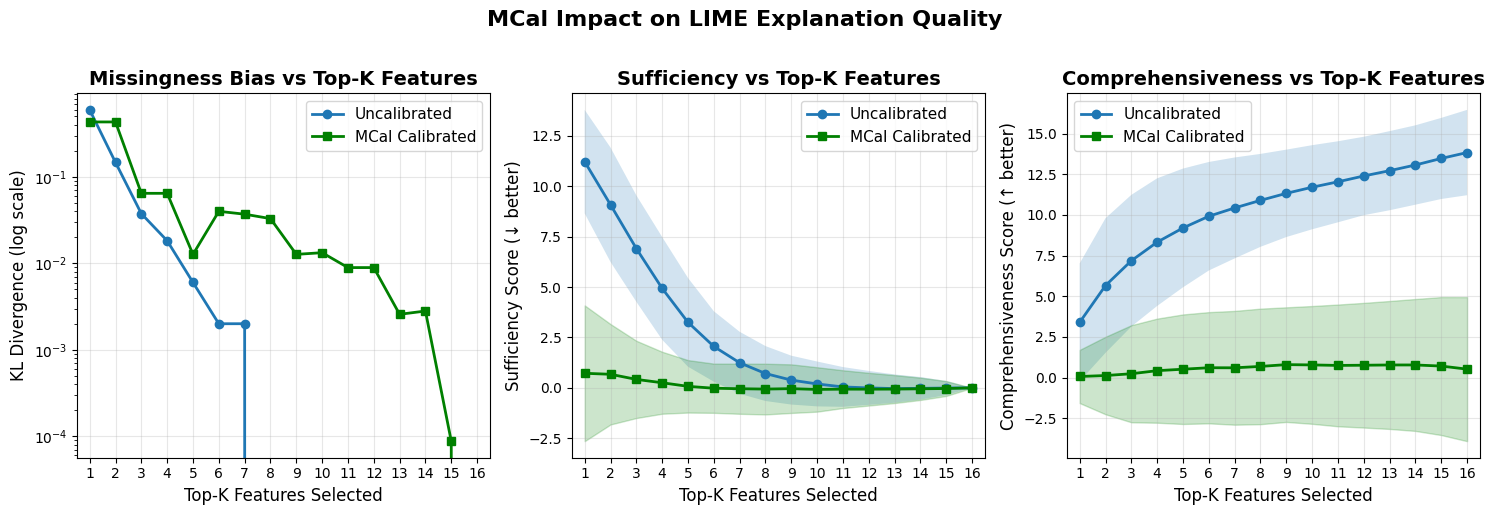

In [11]:
# Create the three key plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

k_vals = config['k_values']

# Plot 1: Missingness Bias (KL Divergence)
axes[0].plot(k_vals, results['missingness_bias']['uncal'], 
             label='Uncalibrated', marker='o', linewidth=2, markersize=6)
axes[0].plot(k_vals, results['missingness_bias']['calib'], 
             label='MCal Calibrated', marker='s', linewidth=2, markersize=6, color='green')
axes[0].set_xlabel('Top-K Features Selected', fontsize=12)
axes[0].set_ylabel('KL Divergence (log scale)', fontsize=12)
axes[0].set_title('Missingness Bias vs Top-K Features', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')
# Show all x values from 1 to 16
axes[0].set_xticks(k_vals)
axes[0].set_xlim(0.5, 16.5)

# Plot 2: Sufficiency
axes[1].plot(k_vals, results['sufficiency']['uncal'], 
             label='Uncalibrated', marker='o', linewidth=2, markersize=6)
axes[1].plot(k_vals, results['sufficiency']['calib'], 
             label='MCal Calibrated', marker='s', linewidth=2, markersize=6, color='green')
axes[1].fill_between(k_vals,
                     np.array(results['sufficiency']['uncal']) - np.array(results['sufficiency_std']['uncal']),
                     np.array(results['sufficiency']['uncal']) + np.array(results['sufficiency_std']['uncal']),
                     alpha=0.2)
axes[1].fill_between(k_vals,
                     np.array(results['sufficiency']['calib']) - np.array(results['sufficiency_std']['calib']),
                     np.array(results['sufficiency']['calib']) + np.array(results['sufficiency_std']['calib']),
                     alpha=0.2, color='green')
axes[1].set_xlabel('Top-K Features Selected', fontsize=12)
axes[1].set_ylabel('Sufficiency Score (↓ better)', fontsize=12)
axes[1].set_title('Sufficiency vs Top-K Features', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_vals)
axes[1].set_xlim(0.5, 16.5)

# Plot 3: Comprehensiveness
axes[2].plot(k_vals, results['comprehensiveness']['uncal'], 
             label='Uncalibrated', marker='o', linewidth=2, markersize=6)
axes[2].plot(k_vals, results['comprehensiveness']['calib'], 
             label='MCal Calibrated', marker='s', linewidth=2, markersize=6, color='green')
axes[2].fill_between(k_vals,
                     np.array(results['comprehensiveness']['uncal']) - np.array(results['comprehensiveness_std']['uncal']),
                     np.array(results['comprehensiveness']['uncal']) + np.array(results['comprehensiveness_std']['uncal']),
                     alpha=0.2)
axes[2].fill_between(k_vals,
                     np.array(results['comprehensiveness']['calib']) - np.array(results['comprehensiveness_std']['calib']),
                     np.array(results['comprehensiveness']['calib']) + np.array(results['comprehensiveness_std']['calib']),
                     alpha=0.2, color='green')
axes[2].set_xlabel('Top-K Features Selected', fontsize=12)
axes[2].set_ylabel('Comprehensiveness Score (↑ better)', fontsize=12)
axes[2].set_title('Comprehensiveness vs Top-K Features', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(k_vals)
axes[2].set_xlim(0.5, 16.5)

plt.suptitle(f'MCal Impact on {config["explanation_method"].upper()} Explanation Quality', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Uncomment to save the figure
# plt.savefig(f'mcal_{config["explanation_method"]}_quality_vs_topk.png', dpi=150, bbox_inches='tight')

plt.show()

## 9. Compute Summary Statistics

In [12]:
# Compute average improvements
avg_kl_improve = np.mean([
    compute_metric_improvement(u, c, 'kl_divergence')
    for u, c in zip(results['missingness_bias']['uncal'],
                    results['missingness_bias']['calib'])
])

avg_suff_improve = np.mean([
    compute_metric_improvement(u, c, 'sufficiency')
    for u, c in zip(results['sufficiency']['uncal'],
                    results['sufficiency']['calib'])
])

avg_comp_improve = np.mean([
    compute_metric_improvement(u, c, 'comprehensiveness')
    for u, c in zip(results['comprehensiveness']['uncal'],
                    results['comprehensiveness']['calib'])
])

print("="*60)
print(f"SUMMARY: MCal Improvement on {config['explanation_method'].upper()} Explanations")
print("="*60)
print(f"\nAverage Improvements Across All K Values:")
print(f"  Missingness Bias (KL): {avg_kl_improve:+.1f}%")
print(f"  Sufficiency: {avg_suff_improve:+.1f}%")
print(f"  Comprehensiveness: {avg_comp_improve:+.1f}%")

SUMMARY: MCal Improvement on LIME Explanations

Average Improvements Across All K Values:
  Missingness Bias (KL): -265.6%
  Sufficiency: -499.2%
  Comprehensiveness: -94.8%


In [13]:
# Show detailed results at key k values
key_k_values = [1, 4, 8, 12, 16]
print("\nDetailed Results at Key K Values:")
print("="*60)

for k in key_k_values:
    idx = k - 1  # Convert to 0-based index
    
    kl_improve = compute_metric_improvement(
        results['missingness_bias']['uncal'][idx],
        results['missingness_bias']['calib'][idx],
        'kl_divergence'
    )
    
    suff_improve = compute_metric_improvement(
        results['sufficiency']['uncal'][idx],
        results['sufficiency']['calib'][idx],
        'sufficiency'
    )
    
    comp_improve = compute_metric_improvement(
        results['comprehensiveness']['uncal'][idx],
        results['comprehensiveness']['calib'][idx],
        'comprehensiveness'
    )
    
    print(f"\nTop-{k} Features:")
    print(f"  KL Divergence: {results['missingness_bias']['uncal'][idx]:.4f} → "
          f"{results['missingness_bias']['calib'][idx]:.4f} ({kl_improve:+.1f}%)")
    print(f"  Sufficiency: {results['sufficiency']['uncal'][idx]:.4f} → "
          f"{results['sufficiency']['calib'][idx]:.4f} ({suff_improve:+.1f}%)")
    print(f"  Comprehensiveness: {results['comprehensiveness']['uncal'][idx]:.4f} → "
          f"{results['comprehensiveness']['calib'][idx]:.4f} ({comp_improve:+.1f}%)")


Detailed Results at Key K Values:

Top-1 Features:
  KL Divergence: 0.5961 → 0.4325 (+27.4%)
  Sufficiency: 11.2156 → 0.7232 (+93.6%)
  Comprehensiveness: 3.4004 → 0.0693 (-98.0%)

Top-4 Features:
  KL Divergence: 0.0183 → 0.0646 (-253.6%)
  Sufficiency: 4.9323 → 0.2540 (+94.9%)
  Comprehensiveness: 8.3309 → 0.4273 (-94.9%)

Top-8 Features:
  KL Divergence: 0.0000 → 0.0330 (+0.0%)
  Sufficiency: 0.7112 → -0.0594 (+108.4%)
  Comprehensiveness: 10.8992 → 0.6888 (-93.7%)

Top-12 Features:
  KL Divergence: 0.0000 → 0.0089 (+0.0%)
  Sufficiency: -0.0007 → -0.0653 (-8763.4%)
  Comprehensiveness: 12.3995 → 0.7620 (-93.9%)

Top-16 Features:
  KL Divergence: 0.0000 → 0.0000 (+0.0%)
  Sufficiency: 0.0000 → 0.0000 (+0.0%)
  Comprehensiveness: 13.8393 → 0.5214 (-96.2%)


## 10. Save Results (Optional)

Uncomment and run the cell below when you're satisfied with the results and want to save them.

In [14]:
# # Uncomment the code below to save results
# 
# # Prepare results for JSON
# results_json = {
#     'k_values': results['k_values'],
#     'missingness_bias': {
#         'uncal': [float(x) for x in results['missingness_bias']['uncal']],
#         'calib': [float(x) for x in results['missingness_bias']['calib']]
#     },
#     'sufficiency': {
#         'uncal': [float(x) for x in results['sufficiency']['uncal']],
#         'calib': [float(x) for x in results['sufficiency']['calib']]
#     },
#     'comprehensiveness': {
#         'uncal': [float(x) for x in results['comprehensiveness']['uncal']],
#         'calib': [float(x) for x in results['comprehensiveness']['calib']]
#     },
#     'config': {
#         'n_train': config['n_train'],
#         'n_test': config['n_test'],
#         'explanation_method': config['explanation_method'],
#         'explanation_samples': config['explanation_samples'],
#         'ablation_rate': config['ablation_rate'],
#         'mcal_steps': config['mcal_steps'],
#         'model': 'ViT MRI'
#     },
#     'improvements': {
#         'kl_divergence_avg': avg_kl_improve,
#         'sufficiency_avg': avg_suff_improve,
#         'comprehensiveness_avg': avg_comp_improve
#     }
# }
# 
# # Save to JSON
# output_file = f"mcal_{config['explanation_method']}_results.json"
# with open(output_file, 'w') as f:
#     json.dump(results_json, f, indent=2)
# 
# print(f"Results saved to {output_file}")
# 
# # Save full results with attributions
# pickle_file = f"mcal_{config['explanation_method']}_full_results.pkl"
# with open(pickle_file, 'wb') as f:
#     pickle.dump({
#         'results': results,
#         'uncal_attrs': uncal_attrs,
#         'calib_attrs': calib_attrs,
#         'config': config
#     }, f)
# 
# print(f"Full results saved to {pickle_file}")

## 11. Visualize Sample Attributions (Optional)

Let's visualize how calibration affects the feature attributions for a sample image.

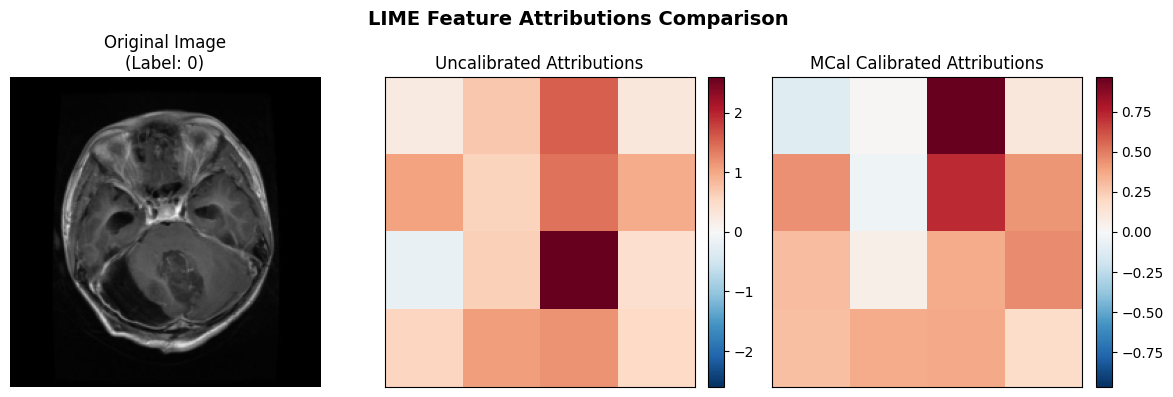


Attribution Statistics:
Uncalibrated - Mean: 0.8502, Std: 0.6532
Calibrated - Mean: 0.3050, Std: 0.2806

Top-3 important patches (0-15):
Uncalibrated: [10, 2, 6]
Calibrated: [2, 6, 11]


In [15]:
# Select a sample image
sample_idx = 0
sample_image = test_images[sample_idx]
sample_label = test_labels[sample_idx].item()

# Get attributions
uncal_attr = uncal_attrs[sample_idx]
calib_attr = calib_attrs[sample_idx]

# Reshape attributions to 4x4 grid
uncal_attr_grid = uncal_attr.reshape(4, 4).cpu().numpy()
calib_attr_grid = calib_attr.reshape(4, 4).cpu().numpy()

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Original image
img_display = sample_image.cpu().permute(1, 2, 0).numpy()
img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())
axes[0].imshow(img_display)
axes[0].set_title(f'Original Image\n(Label: {sample_label})', fontsize=12)
axes[0].axis('off')

# Uncalibrated attributions
im1 = axes[1].imshow(uncal_attr_grid, cmap='RdBu_r', vmin=-np.abs(uncal_attr_grid).max(), 
                     vmax=np.abs(uncal_attr_grid).max())
axes[1].set_title('Uncalibrated Attributions', fontsize=12)
axes[1].set_xticks([])
axes[1].set_yticks([])
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# Calibrated attributions
im2 = axes[2].imshow(calib_attr_grid, cmap='RdBu_r', vmin=-np.abs(calib_attr_grid).max(), 
                     vmax=np.abs(calib_attr_grid).max())
axes[2].set_title('MCal Calibrated Attributions', fontsize=12)
axes[2].set_xticks([])
axes[2].set_yticks([])
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.suptitle(f'{config["explanation_method"].upper()} Feature Attributions Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print statistics
print(f"\nAttribution Statistics:")
print(f"Uncalibrated - Mean: {uncal_attr.mean():.4f}, Std: {uncal_attr.std():.4f}")
print(f"Calibrated - Mean: {calib_attr.mean():.4f}, Std: {calib_attr.std():.4f}")
print(f"\nTop-3 important patches (0-15):")
print(f"Uncalibrated: {torch.argsort(torch.abs(uncal_attr), descending=True)[:3].tolist()}")
print(f"Calibrated: {torch.argsort(torch.abs(calib_attr), descending=True)[:3].tolist()}")

## Conclusions

This experiment demonstrates that MCal calibration:

1. **Reduces missingness bias** - Lower KL divergence between clean and ablated predictions
2. **Improves sufficiency** - Less confidence drop when keeping only important features
3. **May affect comprehensiveness** - Results vary depending on the explanation method

The improvements are most pronounced for smaller k values (higher ablation rates), which aligns with the MCal paper's findings.